# Tech Challenge - Previsão do Nível de Obesidade

Este notebook apresenta o desenvolvimento de uma pipeline de Machine Learning para prever o nível de obesidade de pacientes com base em fatores comportamentais, histórico familiar e estilo de vida.

O objetivo é apoiar a tomada de decisão da equipe médica por meio de um modelo preditivo, conforme proposto no Tech Challenge da Fase 4.

A solução foi construída com foco em:
- análise exploratória dos dados;
- prevenção de data leakage;
- comparação entre diferentes modelos;
- avaliação de overfitting;
- escolha de um modelo seguro e interpretável;
- preparação do modelo para deploy em Streamlit.

In [105]:
#pip install pandas

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

import joblib

## Carregamento dos Dados

A base utilizada no projeto é o arquivo `Obesity.csv`, disponibilizado no desafio.

In [107]:
df = pd.read_csv("Obesity.csv")

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [108]:
print("Quantidade de linhas e colunas:", df.shape)

Quantidade de linhas e colunas: (2111, 17)


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [110]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [111]:
df["Obesity"].value_counts()

,count
Obesity,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


## Qualidade dos Dados

Nesta etapa são verificados valores nulos, duplicatas e possíveis inconsistências.

In [112]:
print("Valores nulos por coluna:")
display(df.isnull().sum())

print("Total de valores nulos:", df.isnull().sum().sum())

Valores nulos por coluna:


,0
Gender,0
Age,0
Height,0
Weight,0
family_history,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


Total de valores nulos: 0


In [113]:
print("Quantidade de duplicatas:", df.duplicated().sum())

Quantidade de duplicatas: 24


In [114]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape após remoção de duplicatas:", df.shape)

Shape após remoção de duplicatas: (2087, 17)


## Análise Exploratória dos Dados

Nesta etapa são analisados os principais padrões presentes na base, com foco na variável alvo e em fatores associados ao nível de obesidade.

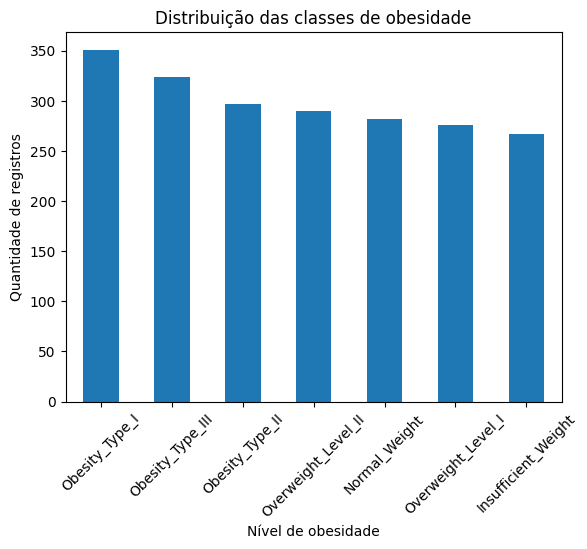

In [115]:
df["Obesity"].value_counts().plot(kind="bar")

plt.title("Distribuição das classes de obesidade")
plt.xlabel("Nível de obesidade")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=45)
plt.show()

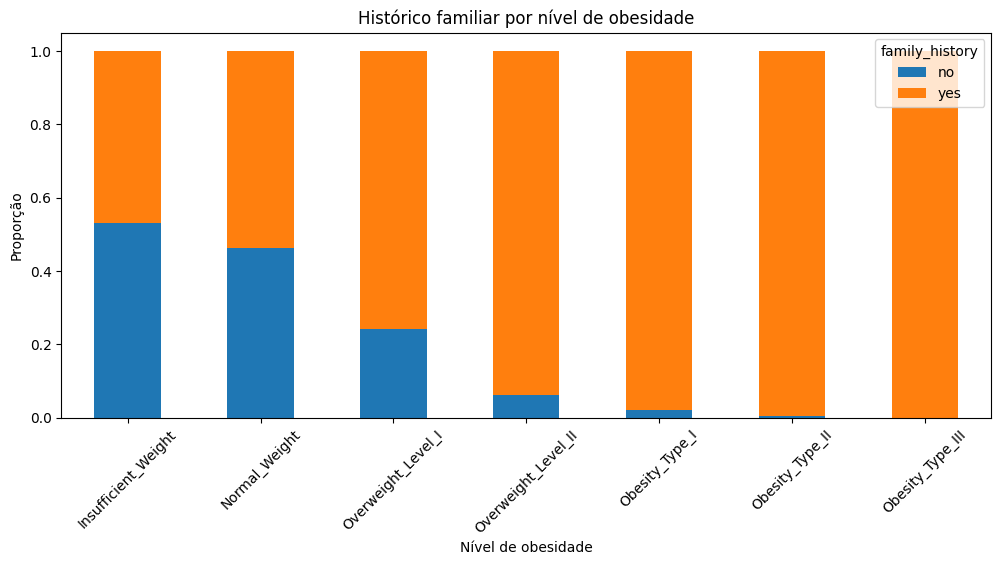

In [116]:
pd.crosstab(
    df["Obesity"],
    df["family_history"],
    normalize="index"
).reindex(ordem_obesidade).plot(kind="bar", stacked=True, figsize=(12,5))

plt.title("Histórico familiar por nível de obesidade")
plt.xlabel("Nível de obesidade")
plt.ylabel("Proporção")
plt.xticks(rotation=45)
plt.show()

O histórico familiar é relevante para avaliar possível predisposição ao sobrepeso e obesidade.

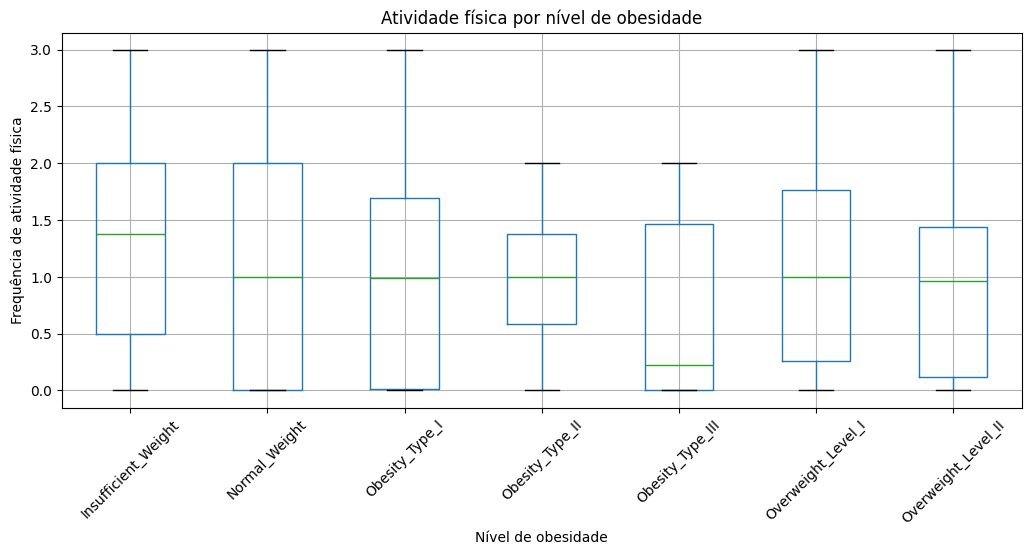

In [117]:
df.boxplot(column="FAF", by="Obesity", figsize=(12,5), rot=45)

plt.title("Atividade física por nível de obesidade")
plt.suptitle("")
plt.xlabel("Nível de obesidade")
plt.ylabel("Frequência de atividade física")
plt.show()

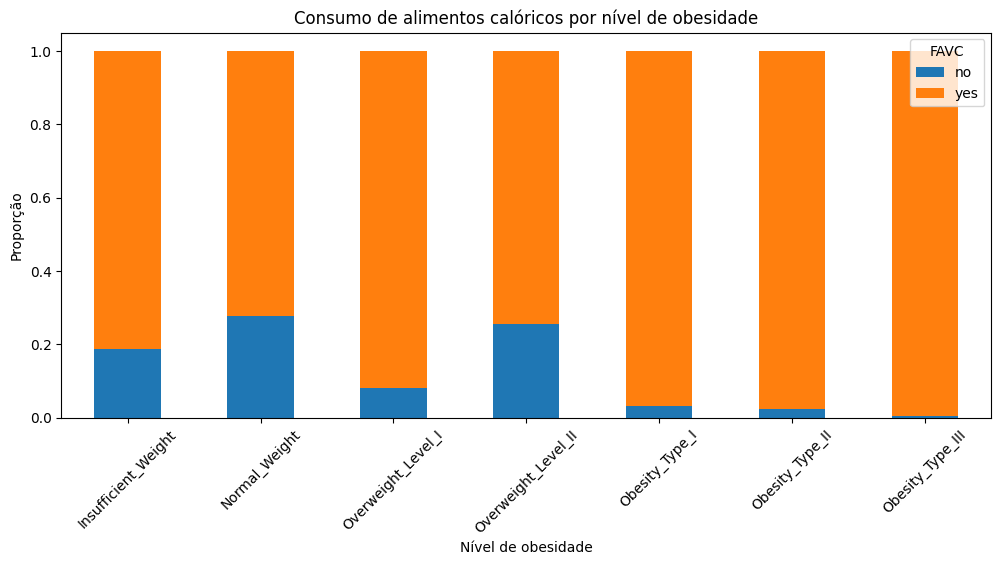

In [118]:
pd.crosstab(
    df["Obesity"],
    df["FAVC"],
    normalize="index"
).reindex(ordem_obesidade).plot(kind="bar", stacked=True, figsize=(12,5))

plt.title("Consumo de alimentos calóricos por nível de obesidade")
plt.xlabel("Nível de obesidade")
plt.ylabel("Proporção")
plt.xticks(rotation=45)
plt.show()

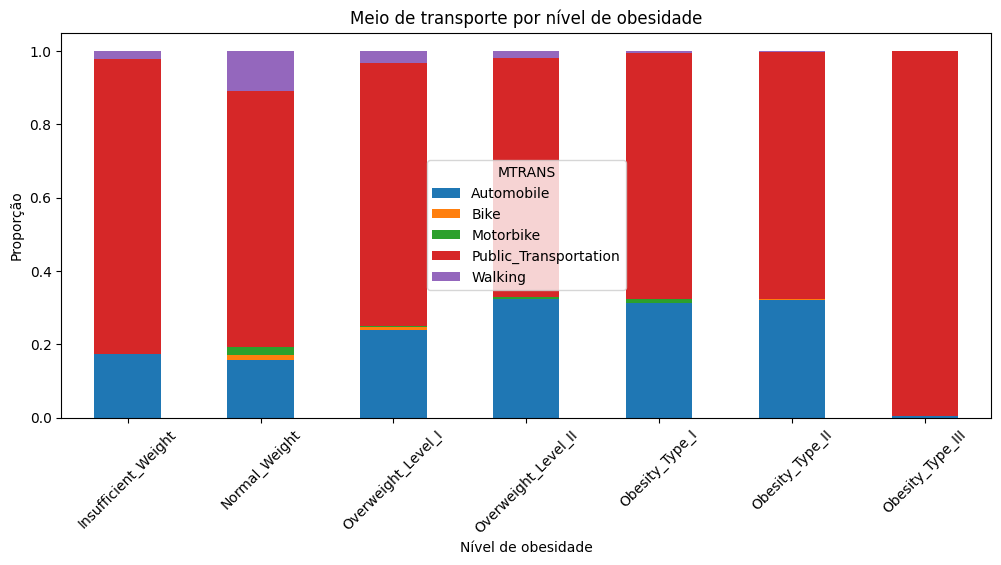

In [119]:
pd.crosstab(
    df["Obesity"],
    df["MTRANS"],
    normalize="index"
).reindex(ordem_obesidade).plot(kind="bar", stacked=True, figsize=(12,5))

plt.title("Meio de transporte por nível de obesidade")
plt.xlabel("Nível de obesidade")
plt.ylabel("Proporção")
plt.xticks(rotation=45)
plt.show()

## Prevenção de Data Leakage

As variáveis `Weight` e `Height` foram removidas da modelagem para reduzir o risco de data leakage.

O nível de obesidade pode estar diretamente relacionado ao IMC, que é calculado a partir de peso e altura. Caso essas variáveis fossem utilizadas no treinamento, o modelo poderia aprender uma relação muito direta com a variável alvo, gerando uma performance artificialmente elevada.

Dessa forma, o modelo final utiliza fatores comportamentais, histórico familiar e estilo de vida, tornando a solução mais adequada como ferramenta de apoio à triagem médica.

In [120]:
X = df.drop(columns=["Obesity", "Weight", "Height"])
y = df["Obesity"]

print("Variáveis preditoras:", X.shape)
print("Variável alvo:", y.shape)

Variáveis preditoras: (2087, 14)
Variável alvo: (2087,)


In [121]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes originais:")
print(label_encoder.classes_)

Classes originais:
['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


In [122]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Colunas categóricas:")
print(categorical_cols)

print("\nColunas numéricas:")
print(numeric_cols)

Colunas categóricas:
['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

Colunas numéricas:
['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


## Separação entre Treino e Teste

A base foi dividida em treino e teste utilizando estratificação, garantindo que a proporção das classes da variável alvo fosse preservada nos dois conjuntos.

In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (1669, 14)
Teste: (418, 14)


In [124]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

O pré-processamento aplica padronização nas variáveis numéricas e One-Hot Encoding nas variáveis categóricas.

## Comparação de Modelos

Foram testados diferentes algoritmos de classificação. A escolha do modelo final considerou não apenas a acurácia, mas também:

- validação cruzada;
- diferença entre treino e teste;
- risco de overfitting;
- capacidade de generalização;
- interpretabilidade para apresentação à equipe médica.

In [125]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=3000),

    "Random Forest sem limite": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Random Forest Ajustado": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "SVC": SVC(
        C=3,
        gamma="scale",
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=15
    )
}

In [126]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados = []

for nome, classificador in modelos.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classificador)
        ]
    )

    pipeline.fit(X_train, y_train)

    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)

    acc_train = accuracy_score(y_train, pred_train)
    acc_test = accuracy_score(y_test, pred_test)

    cv_scores = cross_val_score(
        pipeline,
        X,
        y_encoded,
        cv=cv,
        scoring="accuracy"
    )

    resultados.append({
        "Modelo": nome,
        "Acurácia Treino": acc_train,
        "Acurácia Teste": acc_test,
        "Gap Treino-Teste": acc_train - acc_test,
        "Média CV": cv_scores.mean(),
        "Desvio CV": cv_scores.std()
    })

resultados_modelos = pd.DataFrame(resultados)

resultados_modelos = resultados_modelos.sort_values(
    by="Média CV",
    ascending=False
)

resultados_modelos

,Modelo,Acurácia Treino,Acurácia Teste,Gap Treino-Teste,Média CV,Desvio CV
1,Random Forest sem limite,1.000000,0.846890,0.153110,0.854812,0.011030
3,Extra Trees,1.000000,0.846890,0.153110,0.825570,0.017914
4,Gradient Boosting,0.952067,0.822967,0.129101,0.806903,0.015095
2,Random Forest Ajustado,0.883164,0.791866,0.091298,0.797319,0.011672
5,SVC,0.897543,0.801435,0.096108,0.793965,0.010460
6,KNN,0.731576,0.691388,0.040188,0.686643,0.018379
0,Logistic Regression,0.629119,0.626794,0.002325,0.610447,0.004286


In [127]:
resultado_formatado = resultados_modelos.copy()

for col in ["Acurácia Treino", "Acurácia Teste", "Gap Treino-Teste", "Média CV", "Desvio CV"]:
    resultado_formatado[col] = (resultado_formatado[col] * 100).round(2)

resultado_formatado.sort_values(by="Média CV", ascending=False)

,Modelo,Acurácia Treino,Acurácia Teste,Gap Treino-Teste,Média CV,Desvio CV
1,Random Forest sem limite,100.00,84.69,15.31,85.48,1.10
3,Extra Trees,100.00,84.69,15.31,82.56,1.79
4,Gradient Boosting,95.21,82.30,12.91,80.69,1.51
2,Random Forest Ajustado,88.32,79.19,9.13,79.73,1.17
5,SVC,89.75,80.14,9.61,79.40,1.05
6,KNN,73.16,69.14,4.02,68.66,1.84
0,Logistic Regression,62.91,62.68,0.23,61.04,0.43


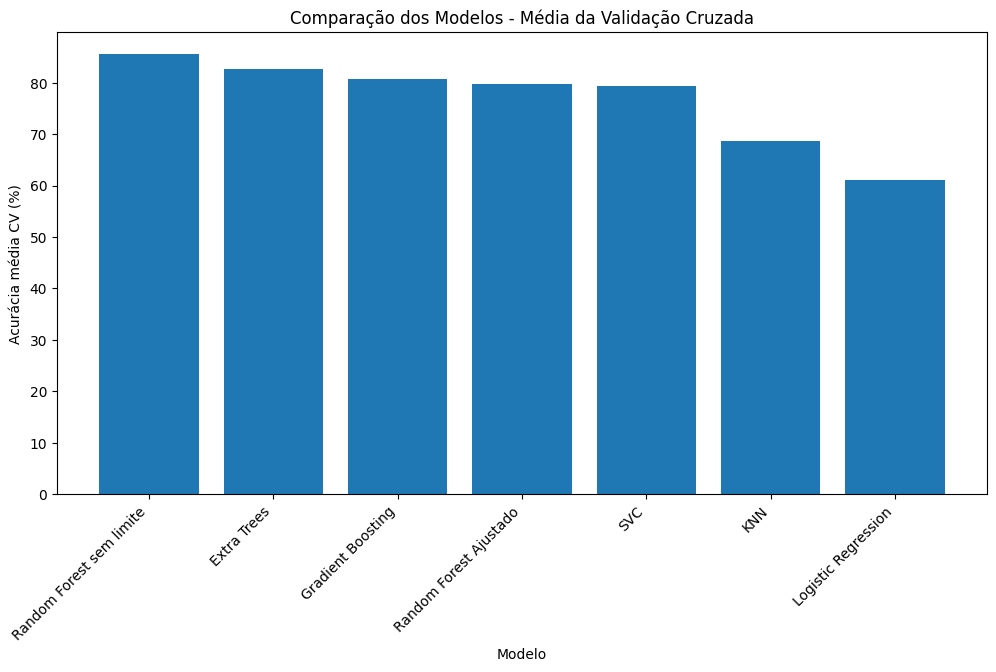

In [128]:
plt.figure(figsize=(12, 6))

plt.bar(
    resultado_formatado["Modelo"],
    resultado_formatado["Média CV"]
)

plt.title("Comparação dos Modelos - Média da Validação Cruzada")
plt.xlabel("Modelo")
plt.ylabel("Acurácia média CV (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Escolha do Modelo Final

Embora alguns modelos tenham apresentado maior acurácia no conjunto de teste, também apresentaram maior diferença entre treino e teste, indicando maior risco de overfitting.

O modelo escolhido foi o **Random Forest Ajustado**, pois apresentou melhor equilíbrio entre:

- acurácia acima do requisito mínimo de 75%;
- menor diferença entre treino e teste;
- validação cruzada consistente;
- menor risco de overfitting;
- boa interpretabilidade por meio da importância das variáveis.

Essa escolha prioriza segurança e capacidade de generalização em vez de maximizar a acurácia a qualquer custo.

In [147]:
modelo_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features="sqrt",
            random_state=42
        ))
    ]
)

modelo_final.fit(X_train, y_train)

y_pred_final = modelo_final.predict(X_test)

accuracy_final = accuracy_score(y_test, y_pred_final)

print("Acurácia Random Forest Ajustado:", accuracy_final)

Acurácia Random Forest Ajustado: 0.7918660287081339


In [148]:
modelo_final.named_steps["classifier"]

RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=300, random_state=42)

In [153]:
train_pred_final = modelo_final.predict(X_train)
test_pred_final = modelo_final.predict(X_test)

train_accuracy_final = accuracy_score(y_train, train_pred_final)
test_accuracy_final = accuracy_score(y_test, test_pred_final)

print("Acurácia treino:", train_accuracy_final)
print("Acurácia teste:", test_accuracy_final)
print("Gap treino-teste:", train_accuracy_final - test_accuracy_final)

Acurácia treino: 0.8831635710005992
Acurácia teste: 0.7918660287081339
Gap treino-teste: 0.09129754229246523


In [150]:
cv_scores_final = cross_val_score(
    modelo_final,
    X,
    y_encoded,
    cv=cv,
    scoring="accuracy"
)

print("Scores CV:", cv_scores_final)
print("Média CV:", cv_scores_final.mean())
print("Desvio CV:", cv_scores_final.std())

Scores CV: [0.80143541 0.78947368 0.79376499 0.8177458  0.78417266]
Média CV: 0.7973185088293001
Desvio CV: 0.011672234452577649


## Avaliação do Modelo Final

Nesta etapa, o modelo final é avaliado por meio do relatório de classificação e da matriz de confusão. Como a variável alvo foi codificada numericamente para o treinamento, as predições são convertidas novamente para os nomes originais das classes.

In [151]:
y_test_texto = label_encoder.inverse_transform(y_test)
y_pred_texto = label_encoder.inverse_transform(y_pred_final)

print(classification_report(y_test_texto, y_pred_texto))

                     precision    recall  f1-score   support

Insufficient_Weight       0.84      0.87      0.85        53
      Normal_Weight       0.68      0.70      0.69        57
     Obesity_Type_I       0.75      0.86      0.80        70
    Obesity_Type_II       0.78      0.97      0.87        60
   Obesity_Type_III       0.98      0.98      0.98        65
 Overweight_Level_I       0.80      0.64      0.71        55
Overweight_Level_II       0.68      0.48      0.57        58

           accuracy                           0.79       418
          macro avg       0.79      0.79      0.78       418
       weighted avg       0.79      0.79      0.78       418



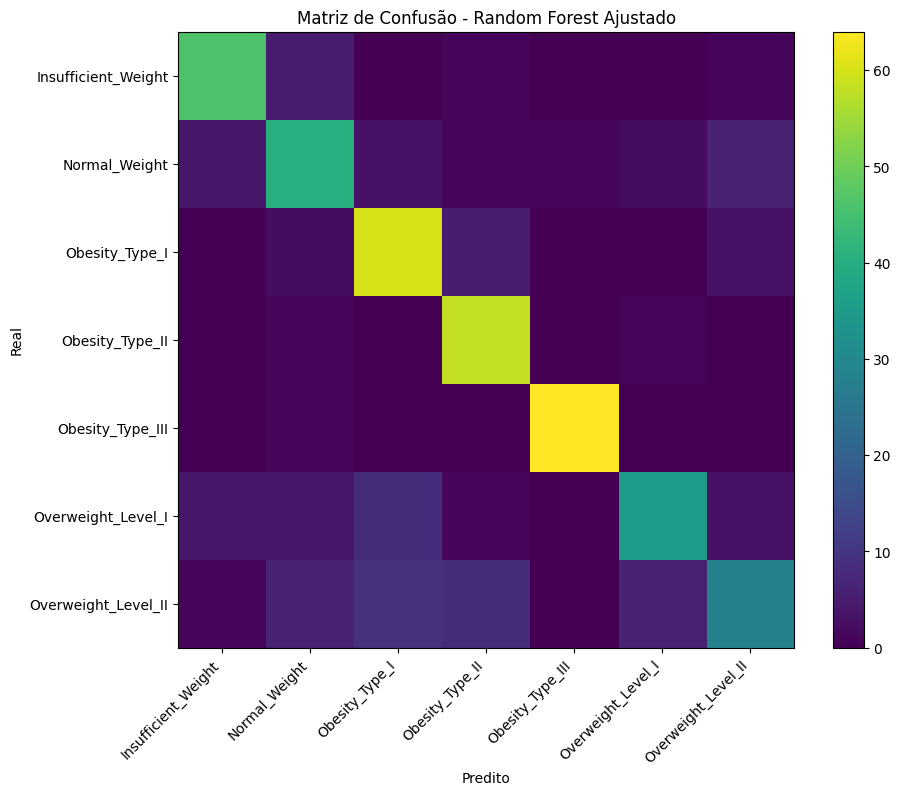

In [152]:
labels = label_encoder.classes_

cm = confusion_matrix(y_test_texto, y_pred_texto, labels=labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Matriz de Confusão - Random Forest Ajustado")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha="right")
plt.yticks(ticks=range(len(labels)), labels=labels)
plt.colorbar()
plt.show()

## Importância das Variáveis

Como o modelo final escolhido foi um Random Forest Ajustado, é possível avaliar a importância das variáveis utilizadas pelo modelo.

Essa análise ajuda a entender quais fatores mais contribuíram para a previsão dos níveis de obesidade.

In [156]:
preprocessor_fitted = modelo_final.named_steps["preprocessor"]
classifier_fitted = modelo_final.named_steps["classifier"]

cat_features = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(categorical_cols)

feature_names = list(numeric_cols) + list(cat_features)

importancias = classifier_fitted.feature_importances_

df_importancias = pd.DataFrame({
    "Feature": feature_names,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)
df_importancias["Importancia (%)"] = (df_importancias["Importancia"] * 100).round(2)

df_importancias.head(15)

,Feature,Importancia,Importancia (%)
1,FCVC,0.151789,15.18
0,Age,0.134160,13.42
2,NCP,0.083743,8.37
5,TUE,0.067484,6.75
4,FAF,0.062506,6.25
3,CH2O,0.061033,6.10
7,Gender_Male,0.056760,5.68
6,Gender_Female,0.054310,5.43
8,family_history_no,0.044957,4.50
22,CALC_Sometimes,0.042092,4.21


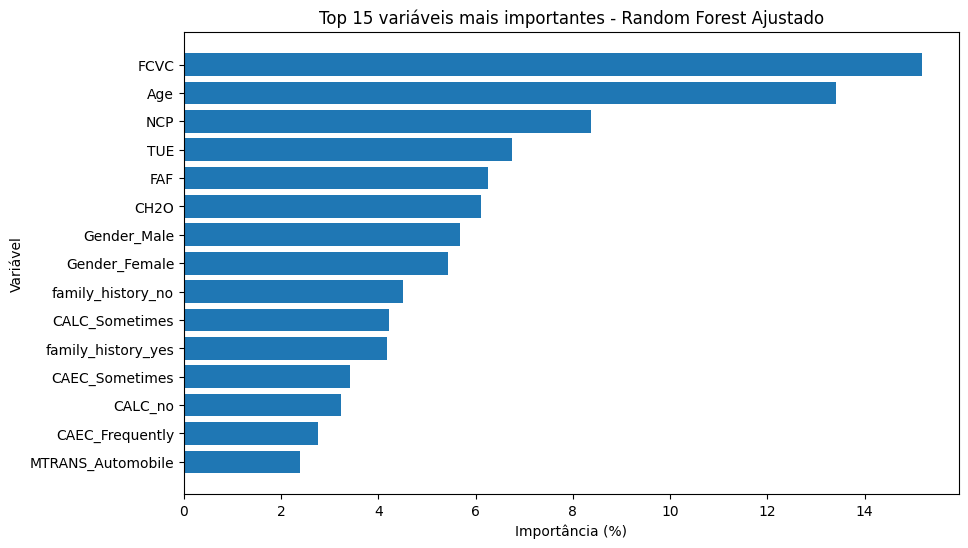

In [157]:
top_features = df_importancias.head(15).sort_values(by="Importancia")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importancia (%)"])
plt.title("Top 15 variáveis mais importantes - Random Forest Ajustado")
plt.xlabel("Importância (%)")
plt.ylabel("Variável")
plt.show()

## Conclusão Final

O modelo final escolhido foi o **Random Forest Ajustado**.

A escolha foi baseada não apenas na acurácia, mas também na análise de overfitting e validação cruzada. Embora modelos como Random Forest sem limite e Extra Trees tenham apresentado maior acurácia no conjunto de teste, ambos atingiram 100% de acurácia no treino, indicando maior risco de overfitting.

O Random Forest Ajustado apresentou acurácia de aproximadamente 79%, média de validação cruzada próxima de 80% e menor diferença entre treino e teste. Dessa forma, foi escolhido por apresentar melhor equilíbrio entre desempenho e capacidade de generalização.

Apesar de apresentarem maior acurácia no conjunto de teste, os modelos Random Forest sem limite e Extra Trees atingiram 100% de acurácia no treino, indicando forte risco de overfitting. Por isso, eles não foram escolhidos como modelo final.

Além disso, as variáveis `Weight` e `Height` foram removidas para reduzir risco de data leakage, tornando a solução mais adequada para uma aplicação de apoio à triagem médica baseada em hábitos, histórico familiar e estilo de vida.

In [160]:
joblib.dump(modelo_final, "modelo_obesidade.pkl")
joblib.dump(list(X.columns), "colunas_modelo.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

df.to_csv("obesity_dashboard.csv", index=False)

print("Arquivos salvos com sucesso!")

Arquivos salvos com sucesso!


In [161]:
modelo_carregado = joblib.load("modelo_obesidade.pkl")
label_encoder_carregado = joblib.load("label_encoder.pkl")

predicoes_teste = modelo_carregado.predict(X_test)

accuracy_loaded_model = accuracy_score(y_test, predicoes_teste)

print("Acurácia do modelo carregado:", accuracy_loaded_model)

Acurácia do modelo carregado: 0.7918660287081339
